<div class="alert alert-block alert-success"> <b>Review General. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Jesus, quería tomarme este espacio al inicio de tu proyecto para comentarte mis apreciaciones generales de esta iteración de tu entrega.

Siempre me gusta comenzar dando la bienvenida al mundo de los datos a los estudiantes. Te deseo lo mejor en este camino y espero que consigas lograr tus objetivos. Personalmente me gusta compartir este consejo: está bien equivocarse. Es normal y, de hecho, es una de las mejores formas de aprender. Los errores te ayudan a descubrir detalles que no siempre se ven a primera vista, y esa experiencia es la que poco a poco te va formando como un mejor analista o científico de datos.

Ahora sí, yendo a esta entrega:

Tu proyecto está muy bien encaminado y presenta un flujo técnico bastante completo para el problema de churn. Cargas las cuatro fuentes necesarias, revisas su calidad, realizas las uniones conservando los 7,043 clientes, construyes correctamente la variable objetivo, desarrollas un análisis exploratorio, preparas las variables y entrenas diferentes modelos de clasificación.

También está muy bien manejada la separación entre entrenamiento, validación y prueba. La codificación de variables categóricas se ajusta únicamente con entrenamiento y haces lo mismo con el escalador, evitando que el conjunto de validación o prueba participe en el ajuste del preprocesamiento. Además, <code>customerID</code>, <code>BeginDate</code> y <code>EndDate</code> quedan fuera de las variables predictoras.

La comparación de modelos es otro punto fuerte. Evalúas Regresión Logística, Random Forest y CatBoost con Accuracy, Precision, Recall, F1 y ROC-AUC. Finalmente seleccionas CatBoost ajustado a partir de validación y reservas el conjunto de prueba para una evaluación final independiente, donde alcanzas un ROC-AUC de aproximadamente 0.8985.

No veo errores bloqueantes para esta iteración. La entrega cumple los criterios principales de la etapa de código de solución y considero que es aprobable.

Los comentarios que te dejo están enfocados principalmente en robustecer el proceso de optimización y en mejorar la comunicación e interpretación del modelo final. En particular, sería interesante fortalecer el ajuste de hiperparámetros con una estrategia de validación más robusta, incorporar alguna visualización de evaluación o interpretabilidad y terminar de cerrar el informe final, que actualmente queda interrumpido en su última recomendación.

Éxitos Jesus.

Saludos.

</div>

# Etapa 1

## 1.1 Plan de trabajo

EL plan es ayudar al equipo de marketing para enfocar promociones a los posibles clientes que se puedan dar de baja de los servicios de telecomunicaciones interconnect
para llegar a esto seguiremos los siguientes pazos:
1. Revision y analisis de los datos
2. Se unificaran las tablas
3. Crearemos una variable objetivo para saber que clientes se han salido
4. Analisis exploratorio de datos
5. Revisar importancia de cada variable para la cancelación
6. Aplicar OHE a las variables categoricas
7. Unir variables creadas con las variables numercas en dataframe
8. escalar variables numericas
9. Se entrenaran los modelos regresion lineal, Random Forest y catboost
10. Usar las metricas Accuray, Precision, Recall, F1 y ROC-AUC
12. Conclusiones

El objetivo mínimo será obtener un AUC-ROC de 0.75, buscando alcanzar valores superiores a 0.88 para lograr un desempeño sobresaliente.

# Etapa 2

## Revisar Datos

In [440]:
import pandas as pd

In [441]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

### Revision Tabla Contract

In [442]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [443]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


TotalCharges object
BeginDate    object
EndDate      object
Estas columnas se analizaran y rvisaremos si necesitamos cambiarlas de tipo

In [444]:
#revisar por queTotalcharger tiene tipo object
contract['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [445]:
#cambiar tipo
contract['TotalCharges'] = pd.to_numeric(
    contract['TotalCharges'],
    errors='coerce'
)
#comprobar
contract['TotalCharges'].dtype


dtype('float64')

In [446]:
#cuántos NaN aparecieron con la conversión
contract['TotalCharges'].isna().sum()


11

In [447]:
#revisemos esas 11 filascontract[contract['TotalCharges'].isna()]

In [448]:
# no se eliminaran estas filas ya que no tienen datos por que se acaban de registrar solo las cambiaremos a 0contract['TotalCharges'] = contract['TotalCharges'].fillna(0)
contract['TotalCharges'] = contract['TotalCharges'].fillna(0)
contract['TotalCharges'].isna().sum()

0

In [449]:
#revisar EndDate
contract['EndDate'].value_counts()

No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: EndDate, dtype: int64

5174 Clientes siguen activos, alrededor de 1800 se han dado de baja

In [450]:
contract['EndDate'].unique()

array(['No', '2019-12-01 00:00:00', '2019-11-01 00:00:00',
       '2019-10-01 00:00:00', '2020-01-01 00:00:00'], dtype=object)

In [451]:
#cambiar No por Nat
contract['EndDate'] = pd.to_datetime(
    contract['EndDate'],
    errors='coerce'
)
contract['EndDate'].dtype
contract['EndDate'].isna().sum()

5174

In [452]:
#En este punto podemos crear la variable Churn que sera el objetivo
contract['Churn'] = contract['EndDate'].notna().astype(int)
contract['Churn'].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

In [453]:
#BeingDate debe ser fecha
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])
contract['BeginDate'].dtype


dtype('<M8[ns]')

In [454]:
#crear la columna Tenuredays, los datos llegan ashata 2020-02-01, entonces esa sera la fecha de corte
reference_date = pd.to_datetime('2020-02-01')

contract['TenureDays'] = (
    contract['EndDate'].fillna(reference_date) - contract['BeginDate']
).dt.days
contract[['BeginDate', 'EndDate', 'TenureDays', 'Churn']].head()
contract['TenureDays'].describe()

count    7043.000000
mean      985.996166
std       747.587844
min         0.000000
25%       273.000000
50%       883.000000
75%      1676.000000
max      2191.000000
Name: TenureDays, dtype: float64

In [455]:
#Revisar las columnas  monthlyCharges y TotalCharges
contract[['MonthlyCharges', 'TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000
mean,64.761692,2279.734304
std,30.090047,2266.794470
min,18.250000,0.000000
25%,35.500000,398.550000
50%,70.350000,1394.550000
75%,89.850000,3786.600000
max,118.750000,8684.800000


In [456]:
print('MonthlyCharges negativos:', (contract['MonthlyCharges'] < 0).sum())
print('TotalCharges negativos:', (contract['TotalCharges'] < 0).sum())

MonthlyCharges negativos: 0
TotalCharges negativos: 0


No se ven valores anomalos o que se necesiten cambiar

Revisar si hay duplicados

In [457]:
contract.duplicated().sum()

0

In [458]:
contract['customerID'].duplicated().sum()

0

In [459]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   Churn             7043 non-null   int64         
 9   TenureDays        7043 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 550.4+ KB


### Conclucion Revision de tabla contract
Se revisó la calidad de los datos de la tabla de contratos. La columna TotalCharges se convirtió a formato numérico y se identificaron 11 valores ausentes correspondientes a clientes nuevos, los cuales se reemplazaron por 0.

Las columnas BeginDate y EndDate se convirtieron a formato de fecha. A partir de EndDate se creó la variable objetivo Churn, donde 0 representa a los clientes activos y 1 a los clientes que cancelaron el servicio. Se identificaron 5,174 clientes activos y 1,869 clientes que cancelaron.

También se creó la variable TenureDays, que representa la antigüedad del cliente en días. Para los clientes activos se utilizó como fecha de referencia el 1 de febrero de 2020.

Las variables categóricas Type, PaperlessBilling y PaymentMethod presentaron categorías consistentes y no requirieron correcciones. Tampoco se encontraron registros duplicados ni identificadores de clientes repetidos.

Finalmente, se revisaron los rangos de MonthlyCharges y TotalCharges y no se identificaron valores anómalos que requirieran tratamiento adicional.

### Revision Tabla Personal

In [460]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [461]:
personal.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [462]:
#revisar consistencia de los datos
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    print(f'\n{col}')
    print(personal[col].value_counts())


gender
Male      3555
Female    3488
Name: gender, dtype: int64

SeniorCitizen
0    5901
1    1142
Name: SeniorCitizen, dtype: int64

Partner
No     3641
Yes    3402
Name: Partner, dtype: int64

Dependents
No     4933
Yes    2110
Name: Dependents, dtype: int64


In [463]:
#Revisar duplicados
print('Filas duplicadas:', personal.duplicated().sum())
print('customerID duplicados:', personal['customerID'].duplicated().sum())

Filas duplicadas: 0
customerID duplicados: 0


### conclución Revision de tabla Personal
La tabla personal contiene 7,043 registros y 5 variables. No se identificaron valores ausentes, filas duplicadas ni identificadores customerID repetidos.

Las variables categóricas gender, Partner y Dependents presentan categorías consistentes y no requieren correcciones. La variable SeniorCitizen se encuentra correctamente representada de forma binaria mediante los valores 0 y 1.

Por lo tanto, no fue necesario realizar modificaciones adicionales en esta tabla.

### Revision Tabla Internet

In [464]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [465]:
display(internet.head(10))

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [466]:
internet.shape

(5517, 8)

In [467]:
for col in internet.columns[1:]:
    print(f'\n{col}')
    print(internet[col].value_counts())


InternetService
Fiber optic    3096
DSL            2421
Name: InternetService, dtype: int64

OnlineSecurity
No     3498
Yes    2019
Name: OnlineSecurity, dtype: int64

OnlineBackup
No     3088
Yes    2429
Name: OnlineBackup, dtype: int64

DeviceProtection
No     3095
Yes    2422
Name: DeviceProtection, dtype: int64

TechSupport
No     3473
Yes    2044
Name: TechSupport, dtype: int64

StreamingTV
No     2810
Yes    2707
Name: StreamingTV, dtype: int64

StreamingMovies
No     2785
Yes    2732
Name: StreamingMovies, dtype: int64


In [468]:
#Revisar duplicados
print('Filas duplicadas:', internet.duplicated().sum())
print('customerID duplicados:', internet['customerID'].duplicated().sum())

Filas duplicadas: 0
customerID duplicados: 0


### Conclucion Tabla Internet

La tabla internet contiene 5,517 registros y 8 variables. No se identificaron valores ausentes, filas duplicadas ni identificadores customerID repetidos.
La tabla contiene menos registros que las tablas contract y personal, debido a que no todos los clientes tienen contratado un servicio de Internet. Esta diferencia se tendrá en cuenta posteriormente durante la integración de las tablas.


### Revision Tabla Phone

In [469]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [470]:
phone.head(10)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


phone.shape

In [471]:
phone['MultipleLines'].value_counts()

No     3390
Yes    2971
Name: MultipleLines, dtype: int64

In [472]:

print('Filas duplicadas:', phone.duplicated().sum())
print('customerID duplicados:', phone['customerID'].duplicated().sum())


Filas duplicadas: 0
customerID duplicados: 0


### Conclucion tabla  Phone

La tabla contiene menos registros que contract, debido a que no todos los clientes tienen contratado el servicio telefónico. Esta diferencia se tendrá en cuenta durante la integración de los datos.

## Union de Tablas

Usaremos Contract como tabla principal ya que es la quee contiene mas datos

In [473]:
#unir contract con personal y guardar en data
data = contract.merge(personal,on='customerID',how='left')
#comprobacion
data.shape

(7043, 14)

In [474]:
#unir data con internet
data = data.merge(internet,on='customerID',how='left')
#comprobacion
data.shape

(7043, 21)

In [475]:
#unir data con phone
data = data.merge(phone, on='customerID',how='left')
data.shape

(7043, 22)

La union debe generar varios valores Nan por las tablas de internet y phone, revisar cuantos son

In [476]:
data.isna().sum()

customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
TenureDays             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

In [477]:
# vamos a llenar los faltandes de las columans con  "no internet service"
internet_cols = ['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

data[internet_cols] = data[internet_cols].fillna('No internet service')
# rellenaremos los datos faltantes de ,ultiplelines con "no phone service"
data['MultipleLines'] = data['MultipleLines'].fillna('No phone service')

#comprobación
data.isna().sum()


customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
TenureDays             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines          0
dtype: int64

In [478]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   Churn             7043 non-null   int64         
 9   TenureDays        7043 non-null   int64         
 10  gender            7043 non-null   object        
 11  SeniorCitizen     7043 non-null   int64         
 12  Partner           7043 non-null   object        
 13  Dependents        7043 non-null   object        
 14  InternetService   7043 n

## Conclución de la union de tablas
Se unieron las tablas utilizando como base la tabla contract, esto creo valores ausentes por las tablas de internet y phone las cuales se rellenaron con el proposito de que nos sirva mas adelante para entrenar el modelo

## Analisis Exploratorio de datos

In [479]:
#analisis de churn
data['Churn'].value_counts(normalize=True) * 100

0    73.463013
1    26.536987
Name: Churn, dtype: float64

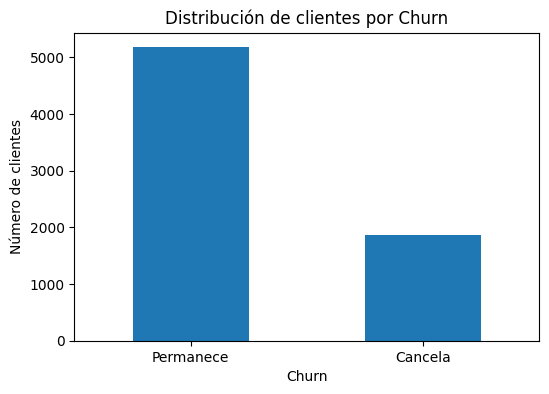

In [480]:
import matplotlib.pyplot as plt

data['Churn'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4))

plt.title('Distribución de clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.xticks([0, 1], ['Permanece', 'Cancela'], rotation=0)
plt.show()

In [481]:
# Analizar las columnas MonthlyCharges,TotalCharges,TenureDays,SeniorCitizen, revisar sus caracteristicas descriptivas
data[['MonthlyCharges', 'TotalCharges', 'TenureDays']].describe()

,MonthlyCharges,TotalCharges,TenureDays
count,7043.000000,7043.000000,7043.000000
mean,64.761692,2279.734304,985.996166
std,30.090047,2266.794470,747.587844
min,18.250000,0.000000,0.000000
25%,35.500000,398.550000,273.000000
50%,70.350000,1394.550000,883.000000
75%,89.850000,3786.600000,1676.000000
max,118.750000,8684.800000,2191.000000


In [482]:
#Revisar los pagos con respecto a los clientes que permanecieron o cancelaron
data.groupby('Churn')[['MonthlyCharges', 'TotalCharges', 'TenureDays']].mean()

,MonthlyCharges,TotalCharges,TenureDays
Churn,,,
0,61.265124,2549.911442,1144.447236
1,74.441332,1531.796094,547.352060


Se observan diferencias entre los clientes que permanecieron y aquellos que cancelaron el servicio. Los clientes que cancelaron presentan un cargo mensual promedio mayor (74.44 frente a 61.27), pero una antigüedad considerablemente menor (547 días frente a 1,144 días).

los clientes que permanecieron presentan mayores cargos totales acumulados, lo cual puede estar relacionado con su mayor antigüedad en la compañía.

Estos resultados sugieren que `MonthlyCharges` y `TenureDays` podrían estar relacionadas con la cancelación de clientes.

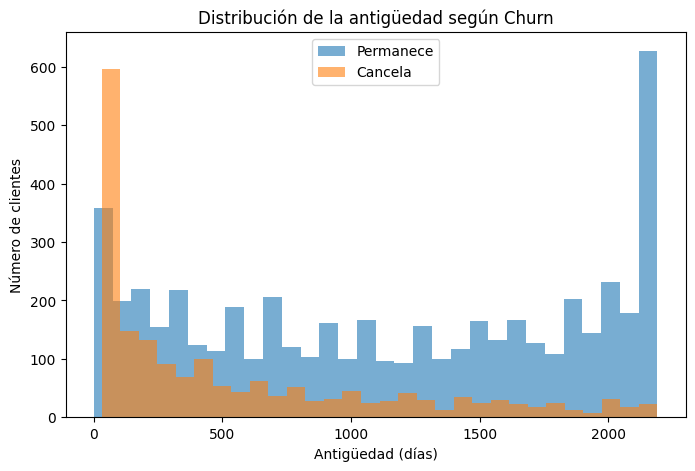

In [483]:
#graficar la antiguedad de los que cancelan o no
plt.figure(figsize=(8, 5))

plt.hist(
    data[data['Churn'] == 0]['TenureDays'],
    bins=30,
    alpha=0.6,
    label='Permanece'
)

plt.hist(
    data[data['Churn'] == 1]['TenureDays'],
    bins=30,
    alpha=0.6,
    label='Cancela'
)

plt.title('Distribución de la antigüedad según Churn')
plt.xlabel('Antigüedad (días)')
plt.ylabel('Número de clientes')
plt.legend()

plt.show()

In [484]:
data.groupby('Churn')['TenureDays'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,1144.447236,733.897937,0.0,457.0,1157.0,1857.0,2191.0
1,1869.0,547.352060,594.389607,30.0,61.0,304.0,883.0,2191.0


Los clientes que cancelan en su mayoria tienen poco tiempo la mediana es de 304 miesntras lo que se quedan tienen 1157, tambien hay quienes cancelan y tienen mucha antiguedad, esta vatiable de antiguedad esta tomando importancia

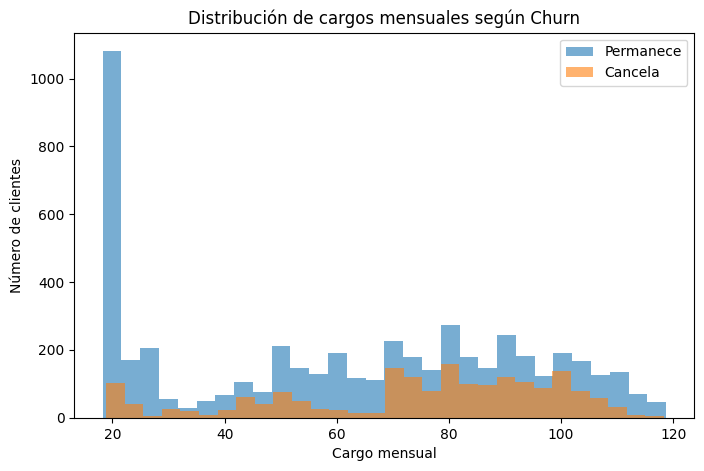

In [485]:
#graficar el cargo mensual de los que cancelan o no
plt.figure(figsize=(8, 5))

plt.hist(
    data[data['Churn'] == 0]['MonthlyCharges'],
    bins=30,
    alpha=0.6,
    label='Permanece'
)

plt.hist(
    data[data['Churn'] == 1]['MonthlyCharges'],
    bins=30,
    alpha=0.6,
    label='Cancela'
)

plt.title('Distribución de cargos mensuales según Churn')
plt.xlabel('Cargo mensual')
plt.ylabel('Número de clientes')
plt.legend()

plt.show()


In [486]:
data.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Los clientes que cancelaron el servicio presentan cargos mensuales más altos que aquellos que permanecieron.

## Revision Variables categoricas

In [487]:
#Revisar la immportancia de los tipos de contratos
data.groupby('Type')['Churn'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Type,,,
Month-to-month,3875,1655,0.427097
One year,1473,166,0.112695
Two year,1695,48,0.028319


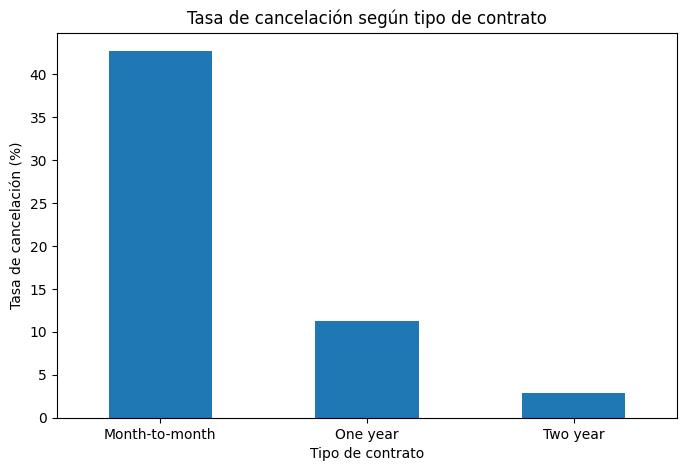

In [488]:
churn_by_type = data.groupby('Type')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))

churn_by_type.plot(kind='bar')

plt.title('Tasa de cancelación según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Tasa de cancelación (%)')
plt.xticks(rotation=0)

plt.show()

Clamente se ve que el contrato Month-to-Month tiene la mayor tase de cancelación es una variable fuerte

In [489]:
#Revisar la immportancia de los tipos de contratos
data.groupby('InternetService')['Churn'].agg(['count', 'sum', 'mean'])

,count,sum,mean
InternetService,,,
DSL,2421,459,0.189591
Fiber optic,3096,1297,0.418928
No internet service,1526,113,0.074050


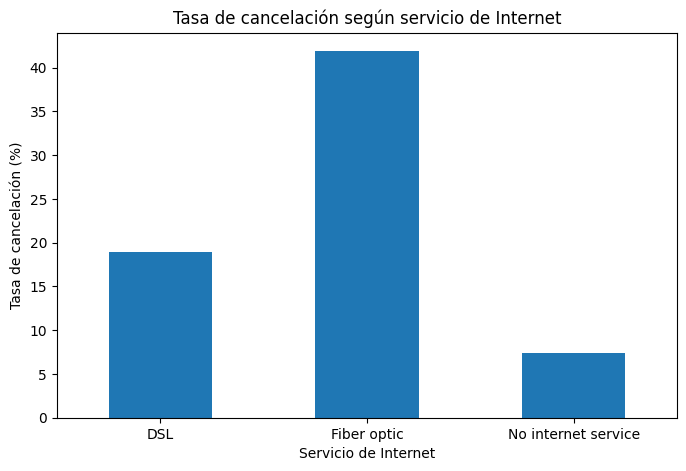

In [490]:
churn_by_internet = data.groupby('InternetService')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))

churn_by_internet.plot(kind='bar')

plt.title('Tasa de cancelación según servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Tasa de cancelación (%)')
plt.xticks(rotation=0)

plt.show()

La tasa de cancelación varía considerablemente según el tipo de servicio de Internet. Los clientes con fibra óptica presentan la mayor tasa de cancelación, con aproximadamente 41.89%, mientras que los clientes con DSL tienen una tasa de 18.96%.

Los clientes sin servicio de Internet presentan la menor tasa de cancelación, con 7.41%.

In [491]:
#Revisar la immportancia del metodo de pago
payment_churn = data.groupby('PaymentMethod')['Churn'].agg(['count', 'sum', 'mean'])

payment_churn

,count,sum,mean
PaymentMethod,,,
Bank transfer (automatic),1544,258,0.167098
Credit card (automatic),1522,232,0.152431
Electronic check,2365,1071,0.452854
Mailed check,1612,308,0.191067


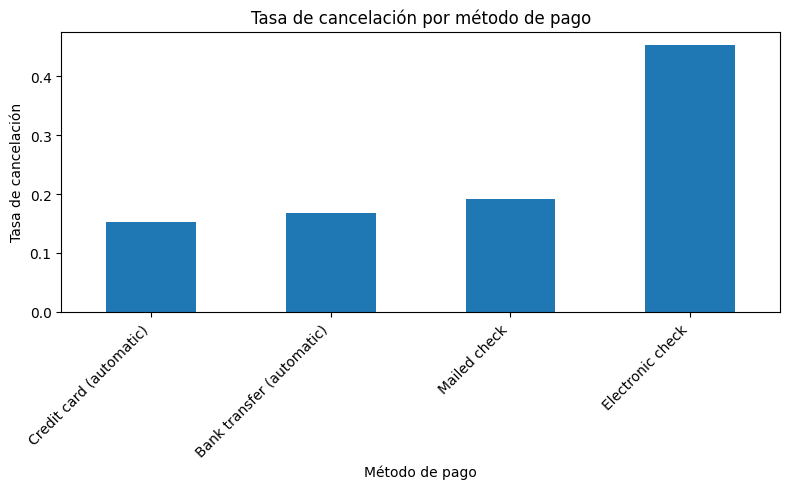

In [492]:
import matplotlib.pyplot as plt

payment_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Tasa de cancelación por método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

los clientes que pagan mediante Electronic check tienen una tasa de cancelación de aproximadamente 45.29%

In [493]:
#Revisar la immportancia de quienes facturan y quienes no

paperless_churn = data.groupby('PaperlessBilling')['Churn'].agg(['count', 'sum', 'mean'])

paperless_churn

,count,sum,mean
PaperlessBilling,,,
No,2872,469,0.163301
Yes,4171,1400,0.335651


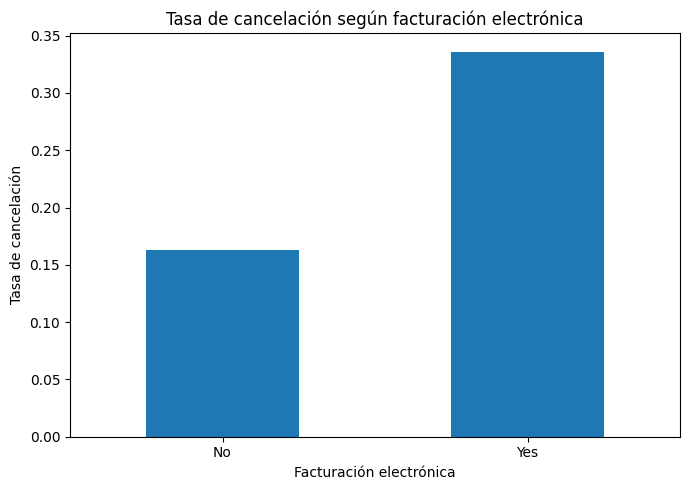

In [494]:
paperless_churn['mean'].plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según facturación electrónica')
plt.xlabel('Facturación electrónica')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

los clientes con facturación electrónica presentan una mayor proporción de cancelaciones. Por lo tanto, `PaperlessBilling` podría ser una variable relevante para predecir el churn de los clientes.

In [495]:
#Revisar la importancia del soporte tecnico.
techsupport_churn = data.groupby('TechSupport')['Churn'].agg(['count', 'sum', 'mean'])

techsupport_churn

,count,sum,mean
TechSupport,,,
No,3473,1446,0.416355
No internet service,1526,113,0.074050
Yes,2044,310,0.151663


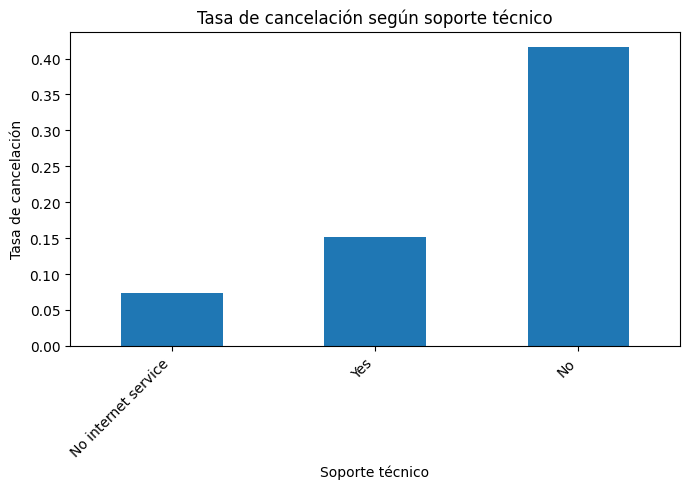

In [496]:
techsupport_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según soporte técnico')
plt.xlabel('Soporte técnico')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Lasociación entre `TechSupport` y la cancelación de clientes. En particular, la ausencia de soporte técnico se relaciona con una mayor proporción de churn, por lo que esta variable podría ser relevante para el modelo predictivo.

In [497]:
#Revisar la immportancia de la seguridad online
security_churn = data.groupby('OnlineSecurity')['Churn'].agg(['count', 'sum', 'mean'])

security_churn

,count,sum,mean
OnlineSecurity,,,
No,3498,1461,0.417667
No internet service,1526,113,0.074050
Yes,2019,295,0.146112


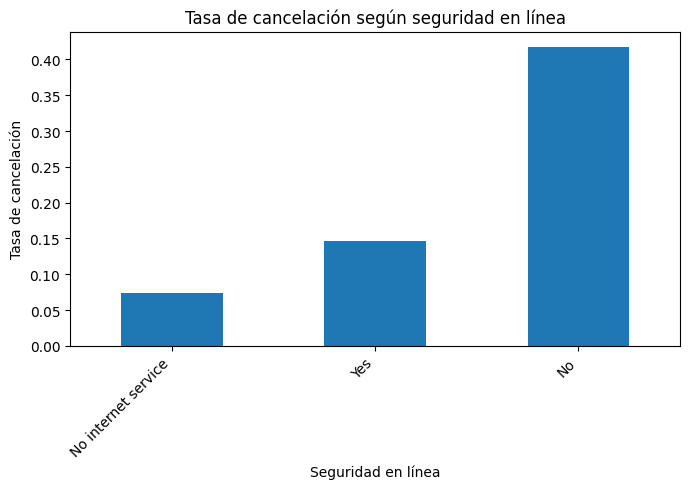

In [498]:
security_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según seguridad en línea')
plt.xlabel('Seguridad en línea')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Nuevamente vemos que los clientes que no tienen seguridad online tienen una mayor tasa de cancelación , esta es una variable fuertementea asociada a la cancelación

In [499]:
#Revisar la immportancia de respaldo de internet

backup_churn = data.groupby('OnlineBackup')['Churn'].agg(['count', 'sum', 'mean'])

backup_churn


,count,sum,mean
OnlineBackup,,,
No,3088,1233,0.399288
No internet service,1526,113,0.074050
Yes,2429,523,0.215315


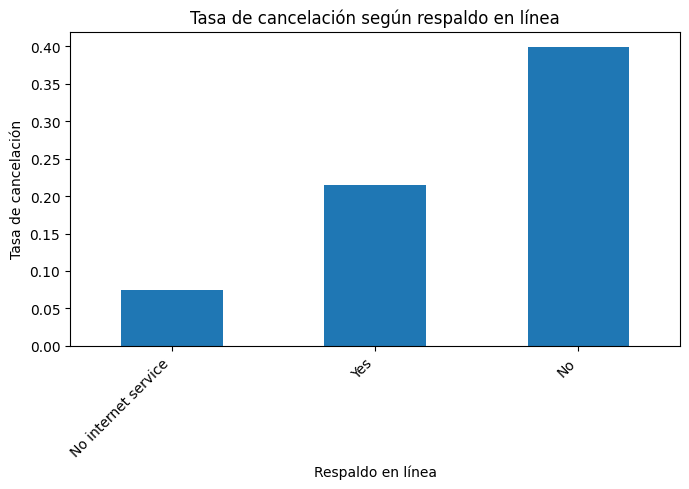

In [500]:
backup_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según respaldo en línea')
plt.xlabel('Respaldo en línea')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Tambien se tiene una asociacion fuerte con respecto a los clientes que cancelaron

In [501]:
#Revisar la importancia de dispositivo de protección
device_churn = data.groupby('DeviceProtection')['Churn'].agg(['count', 'sum', 'mean'])

device_churn

,count,sum,mean
DeviceProtection,,,
No,3095,1211,0.391276
No internet service,1526,113,0.074050
Yes,2422,545,0.225021


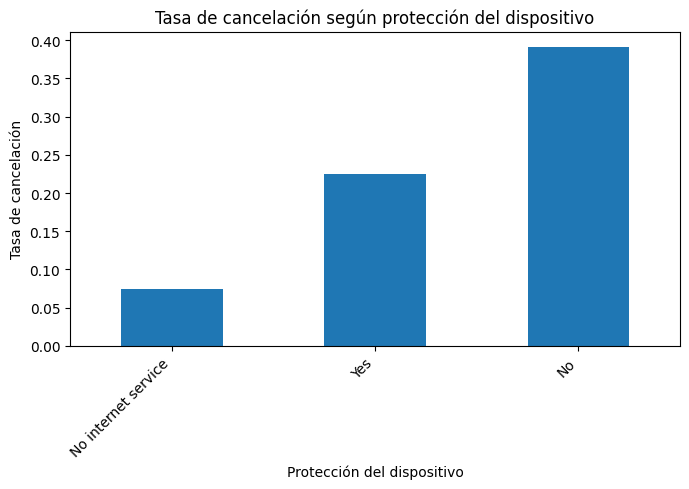

In [502]:
device_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según protección del dispositivo')
plt.xlabel('Protección del dispositivo')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

los clientes que no cuentan con protección de dispositivo cancelan con mayor frecuencia.

In [503]:
#Revisar la importancia de TV streaming
streaming_tv_churn = data.groupby('StreamingTV')['Churn'].agg(['count', 'sum', 'mean'])

streaming_tv_churn


,count,sum,mean
StreamingTV,,,
No,2810,942,0.335231
No internet service,1526,113,0.074050
Yes,2707,814,0.300702


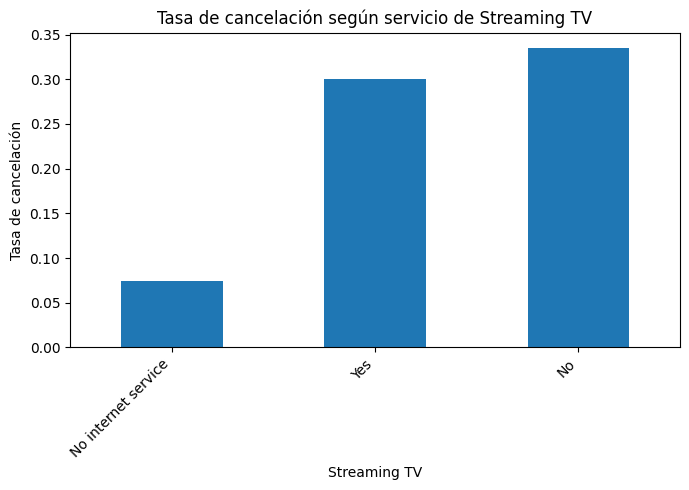

In [504]:
streaming_tv_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según servicio de Streaming TV')
plt.xlabel('Streaming TV')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Al parecer el tener servicio de estreaming o no no afecta fuertemente la cancelación

In [505]:
#Revisar la importancia de peliculas streaming
streaming_movies_churn = data.groupby('StreamingMovies')['Churn'].agg(['count', 'sum', 'mean'])

streaming_movies_churn

,count,sum,mean
StreamingMovies,,,
No,2785,938,0.336804
No internet service,1526,113,0.074050
Yes,2732,818,0.299414


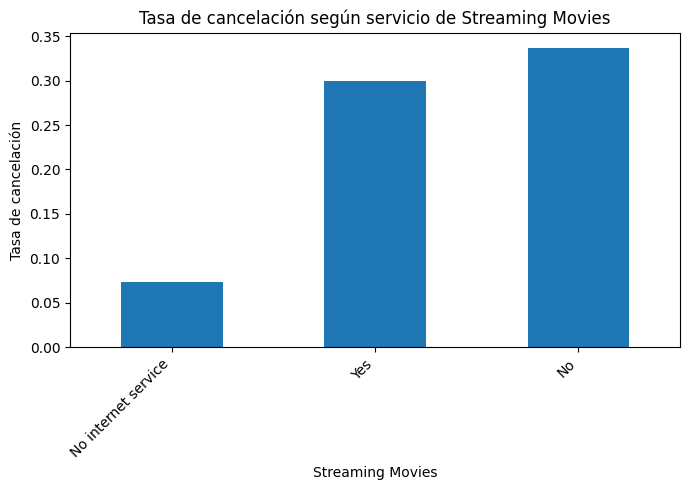

In [506]:
streaming_movies_churn['mean'].sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Tasa de cancelación según servicio de Streaming Movies')
plt.xlabel('Streaming Movies')
plt.ylabel('Tasa de cancelación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

No existe una diferencia fuertemente marcada

In [507]:
data.select_dtypes(include='object').columns

Index(['customerID', 'Type', 'PaperlessBilling', 'PaymentMethod', 'gender',
       'Partner', 'Dependents', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'MultipleLines'],
      dtype='object')

In [508]:
#Analisar cuatro variables genero, pareja, dependiente multiple servicios
categorical_remaining = ['gender', 'Partner', 'Dependents', 'MultipleLines']

for column in categorical_remaining:
    print(f'\n--- {column} ---')
    print( data.groupby(column)['Churn'] .agg(['count', 'sum', 'mean']))


--- gender ---
        count  sum      mean
gender                      
Female   3488  939  0.269209
Male     3555  930  0.261603

--- Partner ---
         count   sum      mean
Partner                       
No        3641  1200  0.329580
Yes       3402   669  0.196649

--- Dependents ---
            count   sum      mean
Dependents                       
No           4933  1543  0.312791
Yes          2110   326  0.154502

--- MultipleLines ---
                  count  sum      mean
MultipleLines                         
No                 3390  849  0.250442
No phone service    682  170  0.249267
Yes                2971  850  0.286099


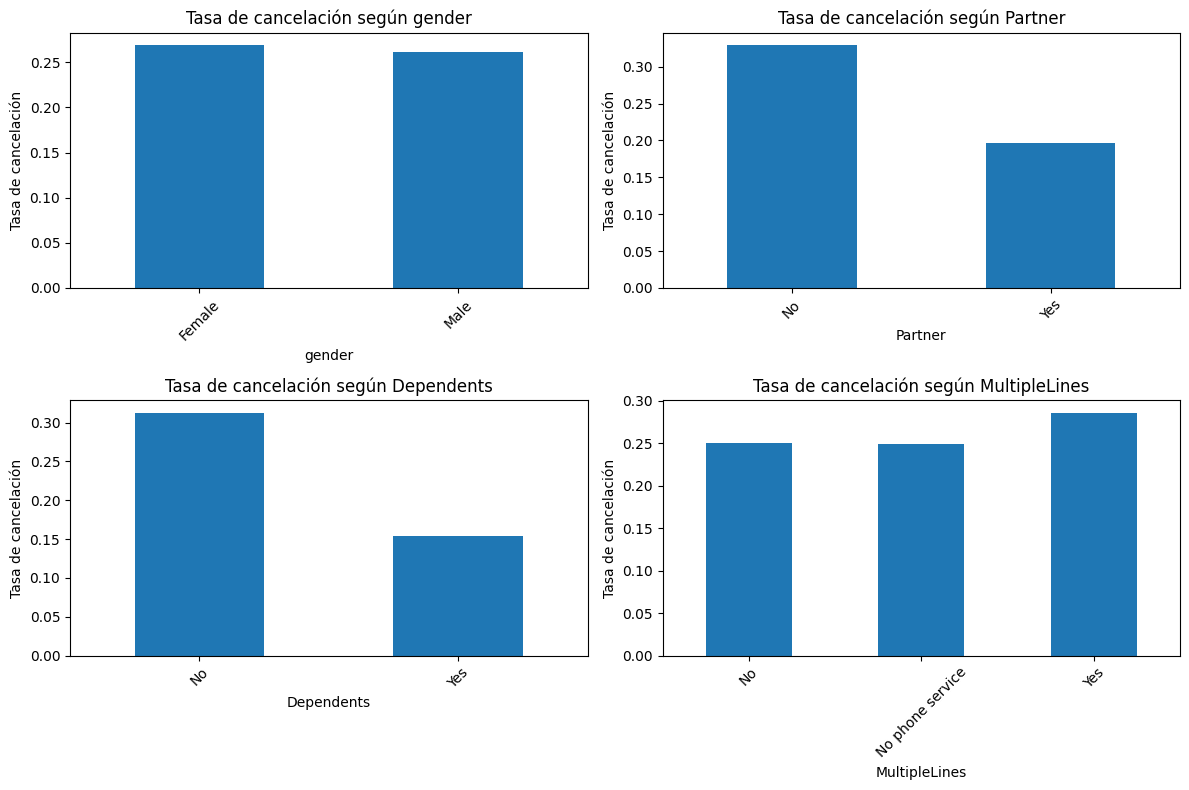

In [509]:
categorical_remaining = ['gender', 'Partner', 'Dependents', 'MultipleLines']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for column, ax in zip(categorical_remaining, axes.flatten()):
    
    churn_rate = data.groupby(column)['Churn'].mean()
    
    churn_rate.plot(
        kind='bar',
        ax=ax )
    
    ax.set_title(f'Tasa de cancelación según {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Tasa de cancelación')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Las variables importantes por su asosiacion son  Partner y dependents muestran una asociación mas fuerte

In [510]:
data.select_dtypes(include='number').columns

Index(['MonthlyCharges', 'TotalCharges', 'Churn', 'TenureDays',
       'SeniorCitizen'],
      dtype='object')

In [511]:
#Revisar cuando  se dieron de baja los clientes
churn_by_month = (data[data['Churn'] == 1] .groupby(data['EndDate'].dt.to_period('M')).size())

churn_by_month

EndDate
2019-10    458
2019-11    485
2019-12    466
2020-01    460
Freq: M, dtype: int64

No hay una tendencia por las temporadas, al parecer solo se registraron las bajas en esos meses.


Como resultado vemos que las variables que tienen relevancia con la cancelación son:
TenureDays
Type
PaymentMethod
InternetService
MonthlyCharges
OnlineSecurity
TechSupport
OnlineBackup
DeviceProtection
Partner
Dependents
PaperlessBilling

## Entrenar Modelos

In [512]:
# limpiaremos la base de datos y definiremos la variable features and target
# vamos a remover  Custumer ID, End Date, Begin Date y churn
features = data.drop(columns=['customerID', 'BeginDate', 'EndDate', 'Churn'])
target = data['Churn']

print('Dimensiones de features:', features.shape)
print('Dimensiones de target:', target.shape)

features.head()

Dimensiones de features: (7043, 18)
Dimensiones de target: (7043,)


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureDays,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,Month-to-month,Yes,Electronic check,29.85,29.85,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service
1,One year,No,Mailed check,56.95,1889.50,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,Month-to-month,Yes,Mailed check,53.85,108.15,61,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,One year,No,Bank transfer (automatic),42.30,1840.75,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service
4,Month-to-month,Yes,Electronic check,70.70,151.65,61,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [513]:
# Separar datos por entrenamiento, validación y prueba,60-20-20 debemos procurar se tenga la misma proposcion den churn por lo cual usaremos stratify
from sklearn.model_selection import train_test_split

# Primera división: 80% train+validation y 20% test
features_train_valid, features_test, target_train_valid, target_test = train_test_split(  features, target, test_size=0.20, random_state=42,stratify=target)

# Segunda división: del 80% restante obtenemos 60% train y 20% validation
features_train, features_valid, target_train, target_valid = train_test_split( features_train_valid, target_train_valid,  test_size=0.25,random_state=42, stratify=target_train_valid)

# Revisar dimensiones
print('Train:', features_train.shape, target_train.shape)
print('Validation:', features_valid.shape, target_valid.shape)
print('Test:', features_test.shape, target_test.shape)

Train: (4225, 18) (4225,)
Validation: (1409, 18) (1409,)
Test: (1409, 18) (1409,)


### Preparar las variables categóricas.

In [514]:
#revisar los datos featues
print('Tipos de datos:')
print(features_train.dtypes)

Tipos de datos:
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
TenureDays            int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MultipleLines        object
dtype: object


### Usar One Hot Enconding

In [515]:
#Revisar las categorias de cada  columna
categorical_columns = features_train.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f'\n{column}:')
    print(features_train[column].value_counts())


Type:
Month-to-month    2326
Two year          1034
One year           865
Name: Type, dtype: int64

PaperlessBilling:
Yes    2524
No     1701
Name: PaperlessBilling, dtype: int64

PaymentMethod:
Electronic check             1410
Mailed check                  980
Bank transfer (automatic)     926
Credit card (automatic)       909
Name: PaymentMethod, dtype: int64

gender:
Male      2139
Female    2086
Name: gender, dtype: int64

Partner:
No     2189
Yes    2036
Name: Partner, dtype: int64

Dependents:
No     2968
Yes    1257
Name: Dependents, dtype: int64

InternetService:
Fiber optic            1843
DSL                    1474
No internet service     908
Name: InternetService, dtype: int64

OnlineSecurity:
No                     2103
Yes                    1214
No internet service     908
Name: OnlineSecurity, dtype: int64

OnlineBackup:
No                     1832
Yes                    1485
No internet service     908
Name: OnlineBackup, dtype: int64

DeviceProtection:
No          

In [516]:
#Primero separaremos las variables numericas de las categoricas
categorical_columns = features_train.select_dtypes(include='object').columns
numeric_columns = features_train.select_dtypes(exclude='object').columns

print('Columnas categóricas:')
print(list(categorical_columns))

print('\nColumnas numéricas:')
print(list(numeric_columns))

Columnas categóricas:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

Columnas numéricas:
['MonthlyCharges', 'TotalCharges', 'TenureDays', 'SeniorCitizen']


In [517]:

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore',sparse=False)

In [518]:
encoder.fit(features_train[categorical_columns])

OneHotEncoder(handle_unknown='ignore', sparse=False)

In [519]:
#Comprobar categorias aprendidas
for column, categories in zip(categorical_columns, encoder.categories_):
    print(column, '->', categories)


Type -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> ['No' 'Yes']
PaymentMethod -> ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check']
gender -> ['Female' 'Male']
Partner -> ['No' 'Yes']
Dependents -> ['No' 'Yes']
InternetService -> ['DSL' 'Fiber optic' 'No internet service']
OnlineSecurity -> ['No' 'No internet service' 'Yes']
OnlineBackup -> ['No' 'No internet service' 'Yes']
DeviceProtection -> ['No' 'No internet service' 'Yes']
TechSupport -> ['No' 'No internet service' 'Yes']
StreamingTV -> ['No' 'No internet service' 'Yes']
StreamingMovies -> ['No' 'No internet service' 'Yes']
MultipleLines -> ['No' 'No phone service' 'Yes']


In [520]:
#Transformar las variables categoricas de entrenamiento, Validación y prueba
train_encoded = encoder.transform(features_train[categorical_columns])
valid_encoded = encoder.transform(features_valid[categorical_columns])
test_encoded = encoder.transform(features_test[categorical_columns])

print('Train:', train_encoded.shape)
print('Validation:', valid_encoded.shape)
print('Test:', test_encoded.shape)

Train: (4225, 39)
Validation: (1409, 39)
Test: (1409, 39)


### convertir OHE en dataframe

In [521]:
#Primero obtenemos los nombres que creó el encoder
encoded_columns = encoder.get_feature_names(categorical_columns)

print(encoded_columns)

['Type_Month-to-month' 'Type_One year' 'Type_Two year'
 'PaperlessBilling_No' 'PaperlessBilling_Yes'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check' 'gender_Female' 'gender_Male' 'Partner_No'
 'Partner_Yes' 'Dependents_No' 'Dependents_Yes' 'InternetService_DSL'
 'InternetService_Fiber optic' 'InternetService_No internet service'
 'OnlineSecurity_No' 'OnlineSecurity_No internet service'
 'OnlineSecurity_Yes' 'OnlineBackup_No' 'OnlineBackup_No internet service'
 'OnlineBackup_Yes' 'DeviceProtection_No'
 'DeviceProtection_No internet service' 'DeviceProtection_Yes'
 'TechSupport_No' 'TechSupport_No internet service' 'TechSupport_Yes'
 'StreamingTV_No' 'StreamingTV_No internet service' 'StreamingTV_Yes'
 'StreamingMovies_No' 'StreamingMovies_No internet service'
 'StreamingMovies_Yes' 'MultipleLines_No' 'MultipleLines_No phone service'
 'MultipleLines_Yes']


In [522]:
train_encoded_df = pd.DataFrame(train_encoded,  columns=encoded_columns, index=features_train.index)

valid_encoded_df = pd.DataFrame(valid_encoded, columns=encoded_columns, index=features_valid.index)

test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns, index=features_test.index)

In [523]:
print(train_encoded_df.shape)
print(valid_encoded_df.shape)
print(test_encoded_df.shape)

(4225, 39)
(1409, 39)
(1409, 39)


In [524]:
#Unir los dataframe con las 4 variables numericas
features_train_final = pd.concat(  [features_train[numeric_columns], train_encoded_df],   axis=1)

features_valid_final = pd.concat(  [features_valid[numeric_columns], valid_encoded_df],  axis=1)

features_test_final = pd.concat( [features_test[numeric_columns], test_encoded_df],  axis=1)

In [525]:
#revisar
print('Train:', features_train_final.shape)
print('Validation:', features_valid_final.shape)
print('Test:', features_test_final.shape)

Train: (4225, 43)
Validation: (1409, 43)
Test: (1409, 43)


### Escalar variables numericas

In [526]:
#escalar columnas conStandarescale, primero separar las variables que se escalaran la señor citizen no se cambiara
columns_to_scale = ['MonthlyCharges','TotalCharges','TenureDays']

In [527]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [528]:
#Solo se hace fit cpn train para que aprenda
scaler.fit(features_train_final[columns_to_scale])

StandardScaler()

In [529]:
#usaremos copias primero por recomendación
features_train_scaled = features_train_final.copy()
features_valid_scaled = features_valid_final.copy()
features_test_scaled = features_test_final.copy()

In [530]:
features_train_scaled[columns_to_scale] = scaler.transform(
    features_train_final[columns_to_scale])

features_valid_scaled[columns_to_scale] = scaler.transform(  features_valid_final[columns_to_scale])

features_test_scaled[columns_to_scale] = scaler.transform(  features_test_final[columns_to_scale])

In [531]:
print(features_train_scaled[columns_to_scale].head())

      MonthlyCharges  TotalCharges  TenureDays
2312       -1.489929     -0.825501   -0.578924
5227        1.047953     -0.721184   -1.023779
6404        1.484829      1.511956    0.799593
88         -1.494931     -0.595135    0.555855
6496        1.236377      0.790441    0.310785


In [532]:
print('Train:', features_train_scaled.shape)
print('Validation:', features_valid_scaled.shape)
print('Test:', features_test_scaled.shape)

Train: (4225, 43)
Validation: (1409, 43)
Test: (1409, 43)


## Entrenar Modelo

Primero comensaremos con un modelo de regresion logistica como base

In [533]:
#entrenar modelo
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42,max_iter=1000)

model_lr.fit(features_train_scaled, target_train)

LogisticRegression(max_iter=1000, random_state=42)

In [534]:
#Predecir con los datos de validación
predictions_valid_lr = model_lr.predict(features_valid_scaled)

In [535]:
predictions_valid_lr

array([1, 1, 1, ..., 0, 1, 0])

In [536]:
#Comparar los resultados con Accuracy
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(target_valid,predictions_valid_lr)

print('Accuracy Regresión Logística:', accuracy_lr)

Accuracy Regresión Logística: 0.8026969481902059


In [537]:
#Comparar los resultados con Precision
from sklearn.metrics import precision_score

precision_lr = precision_score(  target_valid, predictions_valid_lr)

print('Precision Regresión Logística:', precision_lr)

Precision Regresión Logística: 0.6578947368421053


In [538]:
#Comparar los resultados con Recall
from sklearn.metrics import recall_score

recall_lr = recall_score(  target_valid,  predictions_valid_lr)

print('Recall Regresión Logística:', recall_lr)

Recall Regresión Logística: 0.5347593582887701


In [539]:
#Comparar los resultados con F1-score
from sklearn.metrics import f1_score

f1_lr = f1_score(target_valid,  predictions_valid_lr)

print('F1 Regresión Logística:', f1_lr)

F1 Regresión Logística: 0.5899705014749264


In [540]:
#Comparar los resultados con ROC-AUC

probabilities_valid_lr = model_lr.predict_proba(features_valid_scaled)

In [541]:
print(probabilities_valid_lr[:5])

[[0.35539886 0.64460114]
 [0.26898368 0.73101632]
 [0.34134136 0.65865864]
 [0.39176948 0.60823052]
 [0.98012692 0.01987308]]


In [542]:
probabilities_one_valid_lr = probabilities_valid_lr[:, 1]

In [543]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(  target_valid,  probabilities_one_valid_lr)

print('ROC-AUC Regresión Logística:', roc_auc_lr)

ROC-AUC Regresión Logística: 0.8362719264253792


## Random forest

Rsultados de Regresion logistica
Accuracy:  0.8027
Precision: 0.6579
Recall:    0.5348
F1:        0.5900
ROC-AUC:   0.8363

In [544]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier( random_state=42)

model_rf.fit( features_train_final, target_train)

RandomForestClassifier(random_state=42)

In [545]:
#Generar predicciónes
predictions_valid_rf = model_rf.predict(features_valid_final)

In [546]:
#Revisar
print(predictions_valid_rf[:20])

[0 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]


In [547]:
#Comparar los resultados con Accuracy
accuracy_rf = accuracy_score(   target_valid, predictions_valid_rf)

print('Accuracy Random Forest:', accuracy_rf)

Accuracy Random Forest: 0.7991483321504613


In [548]:
#Comparar los resultados con Presicion
precision_rf = precision_score(  target_valid, predictions_valid_rf)

print('Precision Random Forest:', precision_rf)

Precision Random Forest: 0.6619217081850534


In [549]:
#Comparar los resultados con Recall
recall_rf = recall_score( target_valid,predictions_valid_rf)

print('Recall Random Forest:', recall_rf)

Recall Random Forest: 0.49732620320855614


In [550]:
#Comparar los resultados con F1 Score
f1_rf = f1_score( target_valid, predictions_valid_rf)

print('F1 Random Forest:', f1_rf)

F1 Random Forest: 0.5679389312977099


In [551]:
#Comparar los resultados con Auc-Roc

probabilities_valid_rf = model_rf.predict_proba(features_valid_final)

probabilities_one_valid_rf = probabilities_valid_rf[:, 1]

In [552]:
roc_auc_rf = roc_auc_score( target_valid, probabilities_one_valid_rf)

print('ROC-AUC Random Forest:', roc_auc_rf)

ROC-AUC Random Forest: 0.8301635278617377


### Ajustar Hyperparametros para random forest

In [553]:
#Cambiaremos los arboles
n_estimators_options = [50, 100, 200, 300]

In [554]:
#Crear bukle para cada estimador
for n in n_estimators_options:
    print(n)

50
100
200
300


In [555]:
for n in n_estimators_options:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    print(model)

RandomForestClassifier(n_estimators=50, random_state=42)
RandomForestClassifier(random_state=42)
RandomForestClassifier(n_estimators=200, random_state=42)
RandomForestClassifier(n_estimators=300, random_state=42)


In [556]:
for n in n_estimators_options:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(features_train_final, target_train)
    
    print('Árboles:', n)

Árboles: 50
Árboles: 100
Árboles: 200
Árboles: 300


In [557]:
#Probaremos con AUc-Roc

In [558]:
for n in n_estimators_options:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(features_train_final, target_train)
    
    probabilities = model.predict_proba(features_valid_final)[:, 1]
    
    roc_auc = roc_auc_score(
        target_valid,
        probabilities
    )
    
    print('Árboles:', n, '- ROC-AUC:', roc_auc)

Árboles: 50 - ROC-AUC: 0.8249037691492935
Árboles: 100 - ROC-AUC: 0.8301635278617377
Árboles: 200 - ROC-AUC: 0.8308765403394559
Árboles: 300 - ROC-AUC: 0.8326874886977189


No mejora realmente contra Regresion logistica, aun que con 300 arboles si mejora el random fores basico

In [559]:
#Ajustar max depth

In [560]:
max_depth_options = [5, 10, 15, 20]

In [561]:
for depth in max_depth_options:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42
    )
    
    model.fit(features_train_final, target_train)
    
    probabilities = model.predict_proba(features_valid_final)[:, 1]
    
    roc_auc = roc_auc_score(
        target_valid,
        probabilities
    )
    
    print('Profundidad:', depth, '- ROC-AUC:', roc_auc)

Profundidad: 5 - ROC-AUC: 0.8446679066883671
Profundidad: 10 - ROC-AUC: 0.847884212973727
Profundidad: 15 - ROC-AUC: 0.8368286445012788
Profundidad: 20 - ROC-AUC: 0.8330917874396134


con profundidad de 10 si mejora contra la regresion logistica

In [562]:
#Ajustar Class-weight
model_rf_balanced = RandomForestClassifier( n_estimators=300, max_depth=10, class_weight='balanced',   random_state=42)

model_rf_balanced.fit( features_train_final, target_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [563]:
predictions_valid_rf_balanced = model_rf_balanced.predict(features_valid_final)

In [564]:
#Verificación
predictions_valid_rf_balanced[:20]

array([1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [565]:
#Comprobar Accuracy
accuracy_rf_balanced = accuracy_score(target_valid, predictions_valid_rf_balanced)

print('Accuracy Random Forest Balanced:', accuracy_rf_balanced)

Accuracy Random Forest Balanced: 0.7885024840312278


In [566]:
#Comprobar Recall
recall_rf_balanced = recall_score(
    target_valid,
    predictions_valid_rf_balanced
)

print('Recall Random Forest Balanced:', recall_rf_balanced)

Recall Random Forest Balanced: 0.713903743315508


In [567]:
#Comprobar Presicion
precision_rf_balanced = precision_score(target_valid,predictions_valid_rf_balanced)

print('Precision Random Forest Balanced:', precision_rf_balanced)

Precision Random Forest Balanced: 0.5829694323144105


In [568]:
#Comprobar F1 score
f1_rf_balanced = f1_score( target_valid, predictions_valid_rf_balanced)

print('F1 Random Forest Balanced:', f1_rf_balanced)

F1 Random Forest Balanced: 0.6418269230769231


In [569]:
#revisar ROc-Auc
probabilities_valid_rf_balanced = model_rf_balanced.predict_proba(features_valid_final)[:, 1]

In [570]:
roc_auc_rf_balanced = roc_auc_score(target_valid,probabilities_valid_rf_balanced)

print('ROC-AUC Random Forest Balanced:', roc_auc_rf_balanced)

ROC-AUC Random Forest Balanced: 0.8448487431863391


# Catboost

In [571]:
from catboost import CatBoostClassifier

In [572]:
#crear modelo base
model_cb = CatBoostClassifier( random_state=42, verbose=0)

In [573]:
#Entrenar modelo
model_cb.fit( features_train_final,target_train)

In [574]:
#crear predicciones
predictions_valid_cb = model_cb.predict(features_valid_final)
predictions_valid_cb[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [575]:
#Evaluar Accuracy
accuracy_cb = accuracy_score(target_valid, predictions_valid_cb)

print('Accuracy CatBoost:', accuracy_cb)

Accuracy CatBoost: 0.8516678495386799


In [576]:
#Evaluar presicion
precision_cb = precision_score(target_valid,predictions_valid_cb)

print('Precision CatBoost:', precision_cb)

Precision CatBoost: 0.7874564459930313


In [577]:
#Evaluar Recal
recall_cb = recall_score(target_valid,predictions_valid_cb)

print('Recall CatBoost:', recall_cb)

Recall CatBoost: 0.6042780748663101


In [578]:
#Evaluar Recal
f1_cb = f1_score(target_valid,predictions_valid_cb)

print('F1 CatBoost:', f1_cb)

F1 CatBoost: 0.6838124054462935


In [579]:
#Evaluar ROC-AUC
probabilities_valid_cb = model_cb.predict_proba(features_valid_final)[:, 1]
roc_auc_cb = roc_auc_score( target_valid, probabilities_valid_cb)

print('ROC-AUC CatBoost:', roc_auc_cb)

ROC-AUC CatBoost: 0.8892079361388824


## Ajustar Hyper parametros de catboost

In [580]:
#ajustar iteraciones
iterations_options = [100, 300, 500, 700]

In [581]:
for iterations in iterations_options:
    model = CatBoostClassifier(iterations=iterations, random_state=42,verbose=0)
    
    model.fit( features_train_final, target_train)
    
    probabilities = model.predict_proba(features_valid_final)[:, 1]
    
    roc_auc = roc_auc_score( target_valid, probabilities)
    
    print('Iterations:', iterations, '- ROC-AUC:', roc_auc)

Iterations: 100 - ROC-AUC: 0.8803211139528274
Iterations: 300 - ROC-AUC: 0.8853948694102146
Iterations: 500 - ROC-AUC: 0.8861608411480534
Iterations: 700 - ROC-AUC: 0.8855950812472552


In [582]:
#Revisar los paremetros utilizados
model_cb.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'Logloss',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': False,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'class_names': [0, 1],
 'random_seed': 42,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'Logloss',
 'learning_rate': 0.019061999395489693,
 'score_

In [583]:
#Cambiar el parametro depth
depth_options = [4, 6, 8, 10]
for depth in depth_options:
    model = CatBoostClassifier(iterations=1000,depth=depth,random_state=42,verbose=0)
    
    model.fit(features_train_final,target_train)
    
    probabilities = model.predict_proba(
        features_valid_final)[:, 1]
    
    roc_auc = roc_auc_score(target_valid,probabilities)
    
    print('Depth:', depth, '- ROC-AUC:', roc_auc)

Depth: 4 - ROC-AUC: 0.8883786716267534
Depth: 6 - ROC-AUC: 0.8892079361388824
Depth: 8 - ROC-AUC: 0.8794350151127643
Depth: 10 - ROC-AUC: 0.8687940788963806


In [584]:
#Cambiar learning rate
learning_rate_options = [0.05, 0.07, 0.10]

In [585]:
for rate in learning_rate_options:
    model = CatBoostClassifier(iterations=1000,depth=6,learning_rate=rate,random_state=42, verbose=0)
    
    model.fit(features_train_final,target_train)
    
    probabilities = model.predict_proba(features_valid_final)[:, 1]
    
    roc_auc = roc_auc_score(target_valid,probabilities)
    
    print('Learning rate:', rate, '- ROC-AUC:', roc_auc)

Learning rate: 0.05 - ROC-AUC: 0.9035431036709809
Learning rate: 0.07 - ROC-AUC: 0.9050698803895734
Learning rate: 0.1 - ROC-AUC: 0.9055968896122348


In [586]:
#Crear el catboost con los mejores parametros
model_cb_tuned = CatBoostClassifier(iterations=1000,depth=6,learning_rate=0.1, random_state=42,verbose=0)

model_cb_tuned.fit(features_train_final,target_train)

In [587]:
#Realizar predicciones con el modelo mejorado
predictions_valid_cb_tuned = model_cb_tuned.predict(features_valid_final)
predictions_valid_cb_tuned[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [588]:
# Evaluación del CatBoost ajustado

accuracy_cb_tuned = accuracy_score(
    target_valid,
    predictions_valid_cb_tuned
)

precision_cb_tuned = precision_score(
    target_valid,
predictions_valid_cb_tuned)

recall_cb_tuned = recall_score(target_valid, predictions_valid_cb_tuned)

f1_cb_tuned = f1_score( target_valid, predictions_valid_cb_tuned)

probabilities_valid_cb_tuned = model_cb_tuned.predict_proba( features_valid_final)[:, 1]

roc_auc_cb_tuned = roc_auc_score( target_valid, probabilities_valid_cb_tuned)

print('Accuracy:', accuracy_cb_tuned)
print('Precision:', precision_cb_tuned)
print('Recall:', recall_cb_tuned)
print('F1:', f1_cb_tuned)
print('ROC-AUC:', roc_auc_cb_tuned)

Accuracy: 0.8658623136976579
Precision: 0.7899686520376176
Recall: 0.6737967914438503
F1: 0.7272727272727272
ROC-AUC: 0.9055968896122348


### Comparación de modelos

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Regresión Logística | 0.8027 | 0.6579 | 0.5348 | 0.5900 | 0.8363 |
| Random Forest base | 0.7991 | 0.6619 | 0.4973 | 0.5679 | 0.8302 |
| Random Forest balanceado | 0.7885 | 0.5830 | **0.7139** | 0.6418 | 0.8448 |
| CatBoost base | 0.8517 | 0.7875 | 0.6043 | 0.6838 | 0.8892 |
| **CatBoost ajustado** | **0.8659** | **0.7900** | 0.6738 | **0.7273** | **0.9056** |

Se evaluaron distintos modelos de clasificación utilizando el conjunto de validación. La regresión logística y Random Forest mostraron un desempeño aceptable, aunque sus resultados fueron inferiores a los obtenidos con CatBoost.

El modelo CatBoost base obtuvo un ROC-AUC de 0.8892 y, después del ajuste de hiperparámetros, su desempeño mejoró. La mejor configuración encontrada utilizó 1000 iteraciones, una profundidad de 6 y una tasa de aprendizaje de 0.1.

El CatBoost ajustado alcanzó una exactitud de 0.8659, una precisión de 0.7900, un recall de 0.6738, un F1 de 0.7273 y un ROC-AUC de 0.9056 en el conjunto de validación. Estos resultados muestran una buena capacidad para distinguir entre los clientes que permanecen y aquellos con mayor probabilidad de cancelar el servicio.

Por lo tanto, se seleccionó el CatBoost ajustado como modelo final. El conjunto de prueba, que no se utilizó durante la selección ni el ajuste de los modelos, se empleará a continuación para realizar la evaluación final de su capacidad de generalización.

In [589]:
# Predicciones del modelo final en el conjunto de prueba

predictions_test_cb = model_cb_tuned.predict(features_test_final)

probabilities_test_cb = model_cb_tuned.predict_proba( features_test_final)[:, 1]

In [590]:
# Evaluación final en el conjunto de prueba

accuracy_test_cb = accuracy_score(target_test, predictions_test_cb)

precision_test_cb = precision_score(target_test,predictions_test_cb)

recall_test_cb = recall_score(target_test,predictions_test_cb)

f1_test_cb = f1_score(target_test,predictions_test_cb)

roc_auc_test_cb = roc_auc_score( target_test,   probabilities_test_cb)

print('RESULTADOS FINALES - TEST')
print('Accuracy:', accuracy_test_cb)
print('Precision:', precision_test_cb)
print('Recall:', recall_test_cb)
print('F1:', f1_test_cb)
print('ROC-AUC:', roc_auc_test_cb)

RESULTADOS FINALES - TEST
Accuracy: 0.85805535841022
Precision: 0.8020833333333334
Recall: 0.6176470588235294
F1: 0.6978851963746223
ROC-AUC: 0.8984990570668321


El modelo CatBoost ajustado fue evaluado finalmente sobre el conjunto de prueba, obteniendo una exactitud de 0.8581, precisión de 0.8021, recall de 0.6176, F1 de 0.6979 y ROC-AUC de 0.8985.

Los resultados son cercanos a los obtenidos previamente en el conjunto de validación, donde el ROC-AUC fue de 0.9056. La ligera disminución observada en algunas métricas es esperable al evaluar el modelo con datos que no fueron utilizados durante el entrenamiento ni durante el ajuste de hiperparámetros.

# Informe de Solución

## Business recommendations and final conclusions

The final CatBoost model achieved an **ROC-AUC of 0.8985** on the test set, with **Accuracy = 0.8581**, **Precision = 0.8021**, **Recall = 0.6176**, and **F1 = 0.6979**. The test ROC-AUC remained close to the validation result (0.9056), indicating reasonably stable performance on unseen data.

From a business perspective, Interconnect can use each customer's predicted churn probability as an early-warning signal. Rather than applying retention campaigns to the entire customer base, Marketing can prioritize customers with the highest predicted risk and offer targeted incentives such as personalized promotions, plan improvements, or additional benefits.

With a recall of approximately 62%, the model identifies a meaningful share of customers who eventually churn. At the same time, precision of approximately 80% means that most customers flagged as churn risks truly belong to the positive class, helping reduce unnecessary retention spending.

A practical strategy would be to segment customers by predicted churn probability into **high-, medium-, and low-risk groups**. High-risk customers can receive proactive retention actions, medium-risk customers can be monitored or targeted with lower-cost campaigns, and low-risk customers can remain under standard engagement strategies. The probability thresholds should be selected according to the financial cost of a retention offer compared with the cost of losing a customer.

Before deploying the model in production, Interconnect should validate the selected decision threshold against business costs, monitor model performance over time, and retrain the model when customer behavior or service conditions change. The model should support Marketing decisions rather than replace business judgment, since it does not identify every future cancellation.

Overall, the project exceeded the initial ROC-AUC target of 0.75 and demonstrates how machine learning can convert customer and service data into actionable information for retention strategy.

